<a href="https://colab.research.google.com/github/LukaM286/movie-success-prediction/blob/main/movie_success_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("=====================CHANGES=======================")
print("=====================CLEAN VERSION=======================")
print("1. split 2. feature engineering 3. X/y selection 4. scaling 5. model 6. evaluation")

=====================CHANGES=======================
=====================CLEAN VERSION=======================
1. split 2. feature engineering 3. X/y selection 4. scaling 5. model 6. evaluation


In [ ]:
import pandas as pd #za tabele
import numpy as np #calculations
import ast # parsing JSON-like

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#movies = pd.read_csv('/content/drive/MyDrive/Podatkovno_rudarjenje/tmdb_5000_movies.csv')
#credits = pd.read_csv('/content/drive/MyDrive/Podatkovno_rudarjenje/tmdb_5000_credits.csv')

In [ ]:
from google.colab import files
uploaded = files.upload()
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

credits = credits.rename(columns={'movie_id': 'id'}) #daj v id pa jih zdruzi
movies = movies.merge(credits, on='id')

print(movies.shape)

Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv
(4803, 23)


In [ ]:
movies = movies[movies['budget'] > 0]
movies = movies[movies['revenue'] > 0]
movies = movies.dropna(subset=['runtime', 'release_date']) #če manjkajo
#definicija success
movies['success'] = (movies['revenue'] >= 1.5 * movies['budget']).astype(int) #novi binarni stoplec (0/1)

X = movies.copy() #input vse informacije, vsi podatki o filmih
y = movies['success'] #cilj, samo en stolpec

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 #80%train,20%test
)

In [ ]:
def get_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str) #string v python objekt oziroma kot seznam
        for m in crew:
            if m['job'] == 'Director': #cez vse ljudje v filmu najdi director, vrni ime, clean feature
                return m['name']
    except:
        return None
    return None


def get_top_cast(cast_str):
    try:
        cast = ast.literal_eval(cast_str)
        return [m['name'] for m in cast if m['order'] < 3] # vrstni red actor-ja v filmu (1 bolj pomemben od 2 ...)
    except:
        return []


def get_genres(g):
    try:
        return [x['name'] for x in ast.literal_eval(g)]
    except:
        return []

In [ ]:
X_train['director'] = X_train['crew'].apply(get_director) #izvleci director -> naredi nov stoplec
X_test['director'] = X_test['crew'].apply(get_director)

director_counts = X_train['director'].value_counts() #v train koliko filmov ima vsak reziser

#vsak film dobi koliko filmov ima njegov reziser
X_train['director_experience'] = X_train['director'].map(director_counts) #nov stolpec "experience"
X_test['director_experience'] = X_test['director'].map(director_counts)

#isto naredi za cast
#nov stoplec z top cast
X_train['cast_list'] = X_train['cast'].apply(get_top_cast)
X_test['cast_list'] = X_test['cast'].apply(get_top_cast)

#kolikokrat se vsak igralec pojavi v mnozici vseh
all_cast = [a for sub in X_train['cast_list'] for a in sub]
cast_counts = Counter(all_cast)

def cast_fame_score(lst):
    if not lst:
        return 0
    return sum(cast_counts.get(a, 0) for a in lst) / len(lst) # (Leo20 + Kate10 + Billy5) / 3

#vsak film dobi fame score
X_train['cast_fame'] = X_train['cast_list'].apply(cast_fame_score)
X_test['cast_fame'] = X_test['cast_list'].apply(cast_fame_score)

#nov stoplec genre_list
X_train['genre_list'] = X_train['genres'].apply(get_genres)
X_test['genre_list'] = X_test['genres'].apply(get_genres)

all_genres = [g for sub in X_train['genre_list'] for g in sub]
top_genres = [g for g, _ in Counter(all_genres).most_common(10)]
#za vsak zanr stolpec in ali je prisoten v filmu
for g in top_genres:
    X_train[g] = X_train['genre_list'].apply(lambda x: int(g in x))
    X_test[g] = X_test['genre_list'].apply(lambda x: int(g in x))

In [ ]:
feature_cols = [
    'budget', 'runtime', 'popularity', 'vote_average',
    'vote_count', 'director_experience', 'cast_fame'
] + top_genres

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]

In [ ]:
X_train['director_experience'] = X_train['director_experience'].fillna(1)
X_test['director_experience'] = X_test['director_experience'].fillna(1)

X_train['cast_fame'] = X_train['cast_fame'].fillna(0)
X_test['cast_fame'] = X_test['cast_fame'].fillna(0)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) #nauci scaler
X_test_scaled = scaler.transform(X_test) #samo uporabi ista pravila

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

ann.fit(X_train_scaled, y_train)
y_pred_ann = ann.predict(X_test_scaled) #

In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3)) #od vseh uspešnih koliko je res uspešnih
    print("Recall:", round(recall_score(y_true, y_pred), 3)) # ali najde vse uspešne
    print("F1:", round(f1_score(y_true, y_pred), 3))

In [ ]:
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("ANN", y_test, y_pred_ann)


=== Logistic Regression ===
Accuracy: 0.738
Precision: 0.784
Recall: 0.823
F1: 0.803

=== Random Forest ===
Accuracy: 0.772
Precision: 0.794
Recall: 0.876
F1: 0.833

=== ANN ===
Accuracy: 0.745
Precision: 0.777
Recall: 0.85
F1: 0.812


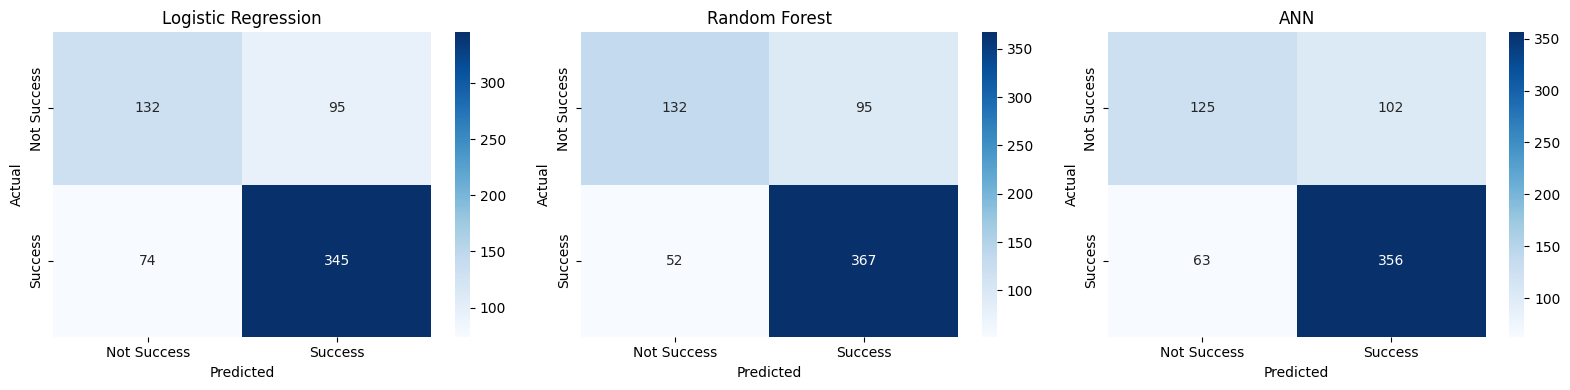

In [ ]:
models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("ANN", y_pred_ann),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Not Success', 'Success'],
        yticklabels=['Not Success', 'Success']
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

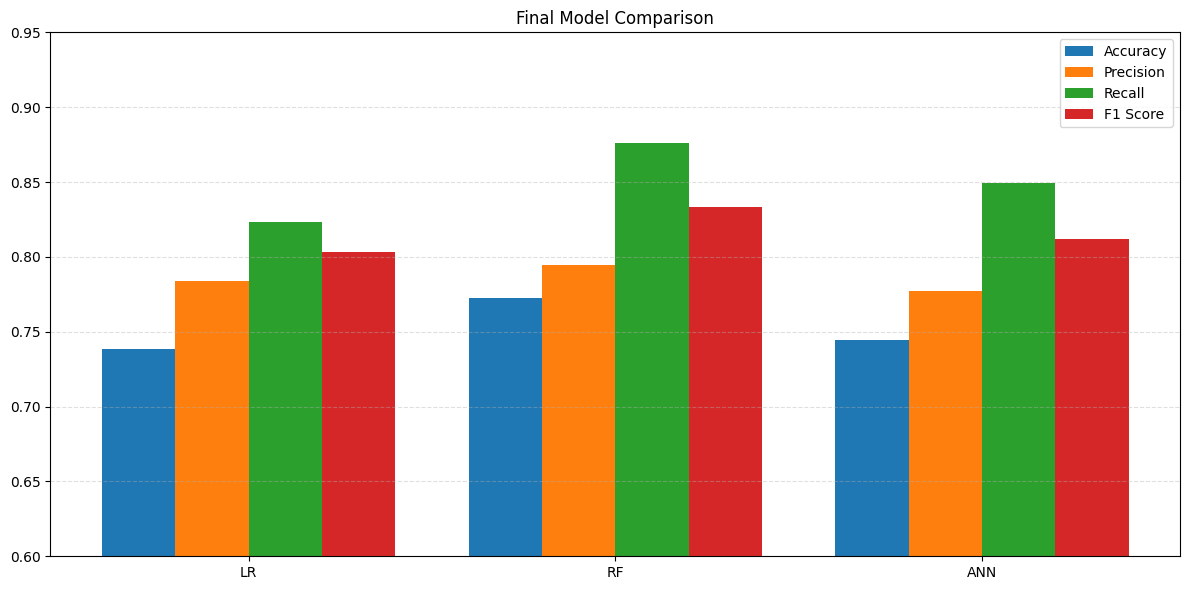

In [ ]:
models = ['LR', 'RF', 'ANN']

metrics = {
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ann),
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ann),
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ann),
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ann),
    ],
}

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, vals) in enumerate(metrics.items()):
    ax.bar(x + i * width, vals, width, label=name)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 0.95)
ax.set_title("Final Model Comparison")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()